# Multi-class Classification - Stock Market Regimes Prediction

# Import libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import yfinance as yf
# display and store Matplotlib plots within a Python Jupyter notebook
%matplotlib inline

In [3]:
import os
#os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

In [4]:
from ta.momentum import (
    RSIIndicator, 
    StochasticOscillator, 
    StochRSIIndicator,
    WilliamsRIndicator,
    UltimateOscillator
)
from ta.volume import MFIIndicator, OnBalanceVolumeIndicator
from ta.trend import MACD, ADXIndicator
from ta.volatility import BollingerBands, AverageTrueRange

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [6]:
import platform
print(f"Python version: {platform.python_version()}")
print(f"Numpy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
import matplotlib
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"yfinance version: {yf.__version__}")
import sklearn
print(f"sklearn version: {sklearn.__version__}")
print(f"Pytorch version: {torch.__version__}")

Python version: 3.12.3
Numpy version: 1.26.4
Pandas version: 2.1.4
Matplotlib version: 3.7.5
Seaborn version: 0.13.2
yfinance version: 1.1.0
sklearn version: 1.4.2
Pytorch version: 2.3.1+cu118


## Fetch historical data

In [7]:
# Fetch S&P500 historical data
ticker = "^SPX"
start_date = '2016-01-01'
end_date = '2026-01-01'  # datetime.now()
#start_date = end_date - timedelta(days=365*10)  # 10 year of data

data = yf.download(ticker, start=start_date, end=end_date, progress=False)

# Flatten the multi-level columns to a single level, yfinance returns MultiIndex
data.columns = data.columns.get_level_values(0)
data.columns = [''.join(col).strip() for col in data.columns.values]
data = data.reset_index()

# Set Date as DatetimeIndex
data['Date'] = pd.to_datetime(data['Date'])
data = data.set_index('Date')

print(f"Downloaded {len(data)} days of ^SPX data")
print(f"Date range: {data.index[0].strftime('%Y-%m-%d')} to {data.index[-1].strftime('%Y-%m-%d')}")
data.head()

Downloaded 2514 days of ^SPX data
Date range: 2016-01-04 to 2025-12-31


,Close,High,Low,Open,Volume
Date,,,,,
2016-01-04,2012.660034,2038.199951,1989.680054,2038.199951,4304880000
2016-01-05,2016.709961,2021.939941,2004.170044,2013.780029,3706620000
2016-01-06,1990.260010,2011.709961,1979.050049,2011.709961,4336660000
2016-01-07,1943.089966,1985.319946,1938.829956,1985.319946,5076590000
2016-01-08,1922.030029,1960.400024,1918.459961,1945.969971,4664940000


#### Helper functions:

In [8]:
# -----------------------------------
#  Compute technical indicators (Using ta library)
# -----------------------------------
# Bounded indicators:
#   - RSI (14 period)
#   - Stochastic Oscillator Fast (%K, %D)
#   - Williams %R (14 period)
#   - Stochastic RSI
#   - Money Flow Index (MFI) (14 period)
#   - Ultimate Oscillator (7, 14, 28 periods)


def calculate_bounded_indicators(df):

    # 1. RSI (14 period)
    rsi = RSIIndicator(close=df['Close'], window=14)
    df['RSI'] = rsi.rsi()
    
    # 2. Stochastic Fast (%K and %D)
    stoch_fast = StochasticOscillator(
        high=df['High'], 
        low=df['Low'], 
        close=df['Close'], 
        window=14, 
        smooth_window=3
    )
    df['STOCH_K'] = stoch_fast.stoch()
    df['STOCH_D'] = stoch_fast.stoch_signal()
    
    # 3. Stochastic Slow
    df['STOCH_SLOW_K'] = df['STOCH_D']
    df['STOCH_SLOW_D'] = df['STOCH_SLOW_K'].rolling(window=3).mean()
    
    # 4. Stochastic RSI
    stoch_rsi = StochRSIIndicator(close=df['Close'], window=14, smooth1=3, smooth2=3)
    df['STOCHRSI'] = stoch_rsi.stochrsi() * 100
    
    # 5. Williams %R
    high_14 = df['High'].rolling(window=14).max()
    low_14 = df['Low'].rolling(window=14).min()
    df['WILLIAMS_R'] = ((high_14 - df['Close']) / (high_14 - low_14)) * -100
    
    # 6. MFI (14 period)
    mfi = MFIIndicator(
        high=df['High'], 
        low=df['Low'], 
        close=df['Close'], 
        volume=df['Volume'], 
        window=14
    )
    df['MFI'] = mfi.money_flow_index()
    
    # 7. Ultimate Oscillator
    ultimate = UltimateOscillator(
        high=df['High'], 
        low=df['Low'], 
        close=df['Close'], 
        window1=7, 
        window2=14, 
        window3=28
    )
    df['ULTIMATE_OSC'] = ultimate.ultimate_oscillator()

    df.dropna(inplace=True)
    return df

In [9]:
# =============================================================================
# INDIVIDUAL INDICATOR CLASSIFICATION
# =============================================================================

def classify_indicator(value, indicator_name):
    """
    Classify individual indicator into 6 consensus categories.
    """
    if pd.isna(value):
        return 'NEUTRAL'
    
    THRESHOLDS = {
        # Format: (strong_oversold, oversold, overbought, strong_overbought)
        'RSI': (20, 30, 70, 80),
        'STOCH_K': (10, 20, 80, 90),
        'STOCH_D': (10, 20, 80, 90),
        'STOCH_SLOW_K': (10, 20, 80, 90),
        'STOCH_SLOW_D': (10, 20, 80, 90),
        'STOCHRSI': (0.10, 0.20, 0.80, 0.90),  # 0-1 scale, not 0-100
        'WILLIAMS_R': (-90, -80, -20, -10),     # Inverted logic
        'MFI': (10, 20, 80, 90),
        'ULTIMATE_OSC': (20, 30, 70, 80)
    }
    
    thresholds = THRESHOLDS[indicator_name]
    strong_os, os, ob, strong_ob = thresholds
    
    # Williams %R is inverted (higher value = more overbought, closer to 0)
    if indicator_name == 'WILLIAMS_R':
        if value <= strong_os:      # <= -90
            return 'STRONG_OVERSOLD'
        elif value <= os:           # <= -80
            return 'OVERSOLD'
        elif value >= strong_ob:    # >= -10
            return 'STRONG_OVERBOUGHT'
        elif value >= ob:           # >= -20
            return 'OVERBOUGHT'
        else:
            return 'NEUTRAL'
    else:
        # Standard 0-100 scale indicators
        if value <= strong_os:
            return 'STRONG_OVERSOLD'
        elif value <= os:
            return 'OVERSOLD'
        elif value >= strong_ob:
            return 'STRONG_OVERBOUGHT'
        elif value >= ob:
            return 'OVERBOUGHT'
        else:
            return 'NEUTRAL'


def classify_all_indicators(df):
    """
    Apply classification to all indicators.
    """
    indicator_cols = ['RSI', 'STOCH_K', 'STOCH_D', 'STOCH_SLOW_K', 'STOCH_SLOW_D', 
                      'STOCHRSI', 'WILLIAMS_R', 'MFI', 'ULTIMATE_OSC']
    
    for col in indicator_cols:
        df[f'{col}_STATUS'] = df[col].apply(lambda x: classify_indicator(x, col))
    
    return df, indicator_cols

In [10]:
# =============================================================================
# CALCULATE CONSENSUS
# =============================================================================

def calculate_consensus(row):
    """
    REFINED CONSENSUS VOTING
    
    Rules:
    1. Strong signals = 2 points, Regular = 1 point
    2. Winner must have weighted score > neutral_count
    3. If both sides present with similar strength → NEUTRAL (conflict)
    4. Ties or insufficient scores → NEUTRAL
    """
    
    # Count categories
    strong_ob = sum(1 for x in row if x == 'STRONG_OVERBOUGHT')
    ob = sum(1 for x in row if x == 'OVERBOUGHT')
    strong_os = sum(1 for x in row if x == 'STRONG_OVERSOLD')
    os = sum(1 for x in row if x == 'OVERSOLD')
    neutral = sum(1 for x in row if x == 'NEUTRAL')
    
    # Weighted scores
    ob_score = strong_ob * 2 + ob
    os_score = strong_os * 2 + os
    
    # Calculate totals
    total_indicators = len(row)
    
    # DEBUG INFO
    debug_info = {
        'strong_ob': strong_ob,
        'ob': ob,
        'ob_score': ob_score,
        'strong_os': strong_os,
        'os': os,
        'os_score': os_score,
        'neutral': neutral,
        'total': total_indicators
    }
    
    # RULE 1: All neutral
    if ob_score == 0 and os_score == 0:
        return 'NEUTRAL', {**debug_info, 'reason': 'ALL_NEUTRAL'}
    
    # RULE 2: Conflict detection - both sides present with similar strength
    if ob_score > 0 and os_score > 0:
        max_score = max(ob_score, os_score)
        min_score = min(ob_score, os_score)
        ratio = min_score / max_score if max_score > 0 else 0
        
        # If weaker side is at least 50% of stronger side → conflict
        if ratio >= 0.5:
            return 'NEUTRAL', {
                **debug_info, 
                'reason': 'CONFLICTING_SIGNALS',
                'ratio': round(ratio, 2)
            }
    
    # RULE 3: Determine winner (higher score)
    if ob_score > os_score:
        winner_score = ob_score
        winner_side = 'OB'
        # Determine strength label
        if strong_ob > ob:
            candidate = 'STRONG_OVERBOUGHT'
        elif strong_ob == ob and strong_ob > 0:
            candidate = 'STRONG_OVERBOUGHT'
        else:
            candidate = 'OVERBOUGHT'
            
    elif os_score > ob_score:
        winner_score = os_score
        winner_side = 'OS'
        # Determine strength label
        if strong_os > os:
            candidate = 'STRONG_OVERSOLD'
        elif strong_os == os and strong_os > 0:
            candidate = 'STRONG_OVERSOLD'
        else:
            candidate = 'OVERSOLD'
            
    else:
        # Exact tie
        return 'NEUTRAL', {**debug_info, 'reason': 'TIED_SCORES'}
    
    # RULE 4: THRESHOLD CHECK - winner must beat neutral
    if winner_score <= neutral:
        return 'NEUTRAL', {
            **debug_info,
            'reason': 'INSUFFICIENT_VS_NEUTRAL',
            'winner_side': winner_side,
            'winner_score': winner_score,
            'threshold_needed': neutral + 1
        }
    
    # PASSED ALL CHECKS
    return candidate, {
        **debug_info,
        'winner_side': winner_side,
        'winner_score': winner_score,
        'margin_vs_neutral': winner_score - neutral,
        'margin_vs_opposite': abs(ob_score - os_score)
    }


def apply_consensus_logic(df, indicator_cols):
    """
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing indicator status columns
    indicator_cols : list
        List of original indicator column names (e.g., ['RSI', 'MFI', ...])
    
    Returns:
    --------
    pandas.DataFrame
        Original dataframe with consensus columns appended

    """
    # Append _STATUS to each indicator name to find the classified columns.
    status_cols = [f'{col}_STATUS' for col in indicator_cols]

    # For each row, extract status values and feed to calculate_consensus
    results = []
    for idx in range(len(df)):
        row = df[status_cols].iloc[idx]
        consensus, details = calculate_consensus(row)
        
        # Map reason to rule number for compatibility
        reason_to_rule = {
            'ALL_NEUTRAL': 1,
            'CONFLICTING_SIGNALS': 2,
            'TIED_SCORES': 3,
            'INSUFFICIENT_VS_NEUTRAL': 4,
            'MAJORITY_WIN': 5
        }

        #  Convert the refined reason codes to numbered rules (1-5) for backward compatibility.
        rule_applied = reason_to_rule.get(
            details.get('reason'), 
            5  # default to majority win
        )

        # Report raw counts (not weighted scores) for OB/OS breakdown, but consensus reflects weighted logic.
        results.append({
            'CONSENSUS': consensus,
            'RULE_APPLIED': rule_applied,
            'NEUTRAL_COUNT': details['neutral'],
            'TOTAL_OB': details['strong_ob'] + details['ob'],
            'TOTAL_OS': details['strong_os'] + details['os'],
            'STRONG_OB_COUNT': details['strong_ob'],
            'OB_COUNT': details['ob'],
            'STRONG_OS_COUNT': details['strong_os'],
            'OS_COUNT': details['os']
        })
    
    results_df = pd.DataFrame(results, index=df.index)
    df = pd.concat([df, results_df], axis=1)
    
    return df


In [11]:
def print_summary(df):
    """
    Print comprehensive summary.
    """
    print("\n" + "=" * 80)
    print("CONSENSUS ANALYSIS")
    print("=" * 80)
    
    print(f"\nPeriod: {df.index[0].date()} to {df.index[-1].date()}")
    print(f"Data set size: {df.shape}")
    #print(f"Current Price: ${df['Close'].iloc[-1]:,.2f}")
    
    print("\n" + "-" * 80)
    print("DISTRIBUTION (All 5 Outcomes)")
    print("-" * 80)
    
    dist = df['CONSENSUS'].value_counts()
    for status in ['STRONG_OVERBOUGHT','OVERBOUGHT', 'NEUTRAL', 'OVERSOLD', 'STRONG_OVERSOLD' ]:
        count = dist.get(status, 0)
        pct = count / len(df) * 100
        bar = "█" * int(pct / 2)
        print(f"  {status:20s}: {count:4d} ({pct:5.2f}%) {bar}")
    

In [12]:
# =============================================================================
# VISUALIZATION
# =============================================================================

def create_visualization(data, output_path):
    """
    Create comprehensive visualization.
    """
    # Color map for regimes
    color_map = {
        "STRONG_OVERBOUGHT": "red",
        "OVERBOUGHT": "orange",
        "NEUTRAL": "lightgray",
        "OVERSOLD": "deepskyblue",
        "STRONG_OVERSOLD": "blue",
    }

    valid_statuses = [
        "STRONG_OVERBOUGHT",        
        "OVERBOUGHT",
        "NEUTRAL",  
        "OVERSOLD",
        "STRONG_OVERSOLD",
    ]

    
    fig, ax_price = plt.subplots(figsize=(14, 6))
    

    # Price line
    ax_price.plot(data.index, data["Close"], color="black", linewidth=1.0)
    
    # Regime-colored background
    current_regime = None
    start_idx = None
    
    for i, (idx, regime) in enumerate(data["CONSENSUS"].items()):
        if regime != current_regime:
            if current_regime is not None:
                ax_price.axvspan(
                    start_idx,
                    prev_idx,
                    color=color_map.get(current_regime, "white"),
                    alpha=0.12,
                    linewidth=0,
                )
            current_regime = regime
            start_idx = idx
        prev_idx = idx
    
    # Close last span
    if current_regime is not None:
        ax_price.axvspan(
            start_idx,
            data.index[-1],
            color=color_map.get(current_regime, "white"),
            alpha=0.12,
            linewidth=0,
        )
    
    # Title and labels
    ax_price.set_title(f"{ticker} Close Price with Regime Consensus ({data.shape[0]} days)")
    ax_price.set_ylabel("Price")
    ax_price.grid(True, alpha=0.3)
    
    # Legend
    from matplotlib.patches import Patch
    legend_patches = [
        Patch(facecolor=color_map[s], edgecolor="none", alpha=0.4, label=s)
        for s in valid_statuses
    ]
    ax_price.legend(handles=legend_patches, loc="upper left")
    
    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()
    
    print(f"\nChart saved: {output_path}")


## Identifying overbought and oversold conditions 


CONSENSUS ANALYSIS

Period: 2016-02-12 to 2025-12-31
Data set size: (2486, 32)

--------------------------------------------------------------------------------
DISTRIBUTION (All 5 Outcomes)
--------------------------------------------------------------------------------
  STRONG_OVERBOUGHT   :  828 (33.31%) ████████████████
  OVERBOUGHT          :  217 ( 8.73%) ████
  NEUTRAL             : 1274 (51.25%) █████████████████████████
  OVERSOLD            :   60 ( 2.41%) █
  STRONG_OVERSOLD     :  107 ( 4.30%) ██


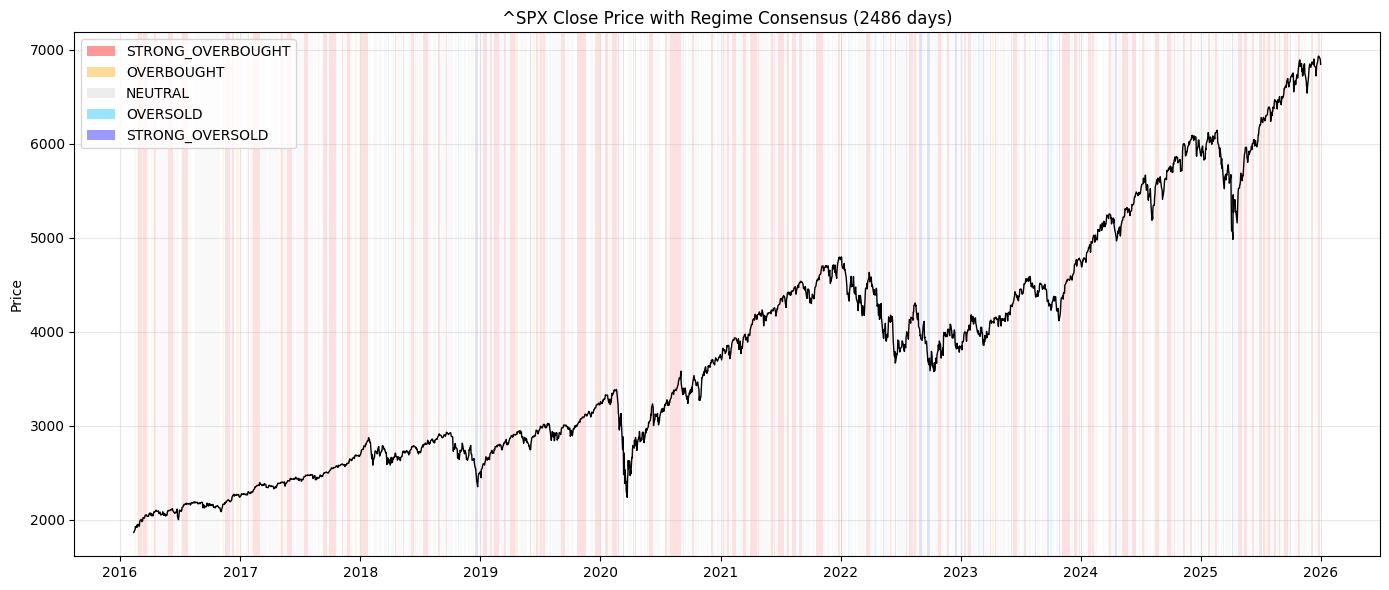


Chart saved: ./Documents/consensus_plot.png


In [13]:
# =============================================================================
# MAIN
# =============================================================================

def main():
    """
    Main execution.
    """
    OUTPUT_CHART = './Documents/consensus_plot.png'
    
    df = calculate_bounded_indicators(data)
    df, indicator_cols = classify_all_indicators(df)
    df = apply_consensus_logic(df, indicator_cols)
    
    print_summary(df)
    create_visualization(df, OUTPUT_CHART)
   
    return df


if __name__ == "__main__":
    df = main()

In [14]:
df.to_excel("./Documents/Identify_market_regimes.xlsx", sheet_name="Detail",  index=True) 

In [15]:
df.shape

(2486, 32)

In [16]:
df2 = df[['Close','High','Low','Open','Volume','RSI','STOCH_K','STOCH_D', 'STOCH_SLOW_K','STOCH_SLOW_D','STOCHRSI','WILLIAMS_R','MFI','ULTIMATE_OSC','CONSENSUS']].copy()

In [17]:
df2.tail()

,Close,High,Low,Open,Volume,RSI,STOCH_K,STOCH_D,STOCH_SLOW_K,STOCH_SLOW_D,STOCHRSI,WILLIAMS_R,MFI,ULTIMATE_OSC,CONSENSUS
Date,,,,,,,,,,,,,,,
2025-12-24,6932.049805,6937.319824,6904.910156,6904.910156,1798270000,61.332223,97.570184,94.451833,94.451833,78.869781,99.262037,-2.429816,57.418341,58.538562,STRONG_OVERBOUGHT
2025-12-26,6929.939941,6945.770020,6921.600098,6936.020020,2586550000,61.078683,92.975020,96.657652,96.657652,91.270762,97.897114,-7.024980,55.906369,56.981304,STRONG_OVERBOUGHT
2025-12-29,6905.740234,6920.209961,6888.759766,6903.600098,3541750000,58.111394,82.235816,90.927007,90.927007,94.012164,81.922832,-17.764184,56.930067,64.788274,STRONG_OVERBOUGHT
2025-12-30,6896.240234,6913.250000,6893.470215,6900.439941,3309930000,56.941893,78.019961,84.410266,84.410266,90.664975,75.626875,-21.980039,57.977809,65.666361,STRONG_OVERBOUGHT
2025-12-31,6845.500000,6901.419922,6844.549805,6898.819824,3261830000,51.034250,55.502756,71.919511,71.919511,82.418928,43.823313,-44.497244,51.098025,52.323325,NEUTRAL


## Features Engineering

In [18]:
# add 5 Unbounded indicators (features engineering)
#
#  Moving Average Convergence Divergence (MACD)
#  Bollinger Bands
#  Average Directional Index (ADX)
#  Average True Range (ATR)
#  On-Balance Volume (OBV)
# 

macd_ind = MACD(close=df2['Close'], window_slow=26, window_fast=12, window_sign=9)
df2["MACD"] = macd_ind.macd()
df2["MACD_SIGNAL"] = macd_ind.macd_signal()
df2["MACD_HIST"] = macd_ind.macd_diff()

bb = BollingerBands(close=df2['Close'], window=20, window_dev=2)
df2["BB_MAVG"] = bb.bollinger_mavg()
df2["BB_HBAND"] = bb.bollinger_hband()
df2["BB_LBAND"] = bb.bollinger_lband()
df2["BB_PBAND"] = bb.bollinger_pband()
df2["BB_WBAND"] = bb.bollinger_wband()

adx_ind = ADXIndicator(high=df2['High'], low=df2['Low'], close=df2['Close'], window=14)
df2["ADX"] = adx_ind.adx()
df2["ADX_POS"] = adx_ind.adx_pos()
df2["ADX_NEG"] = adx_ind.adx_neg()

atr_ind = AverageTrueRange(high=df2['High'], low=df2['Low'], close=df2['Close'], window=14)
df2["ATR"] = atr_ind.average_true_range()

obv_ind = OnBalanceVolumeIndicator(close=df2['Close'], volume=df2['Volume'])
df2["OBV"] = obv_ind.on_balance_volume()

df2.dropna(inplace=True)


In [19]:
df2.to_excel("./Documents/Identify_market_regimes_fe.xlsx", sheet_name="Detail",  index=True) 

In [20]:
df2.shape

(2453, 28)

### The consensus labels are based on single‑day bounded indicators RSI, Stoch, Williams %R, MFI, StochRSI → all computed from same day’s price action.
### So the target is inherently single‑day dependent.

In [21]:
df3 = df2.copy()

In [22]:
target_classes = [
    "STRONG_OVERBOUGHT",
    "OVERBOUGHT",
    "NEUTRAL",
    "OVERSOLD",
    "STRONG_OVERSOLD"
]

# Assign numeric levels (reverse index so top=4, bottom=0)

class_to_idx = {
    "STRONG_OVERBOUGHT": 4,
    "OVERBOUGHT": 3,
    "NEUTRAL": 2,
    "OVERSOLD": 1,
    "STRONG_OVERSOLD": 0
}

idx_to_class = {i: c for c, i in class_to_idx.items()}
df3["TARGET_IDX"] = df3["CONSENSUS"].map(class_to_idx) # categorical to numerical encoding

feature_cols = df3.columns.difference(['CONSENSUS','TARGET_IDX']).tolist()  

X = df3[feature_cols].values
y = df3["TARGET_IDX"].values

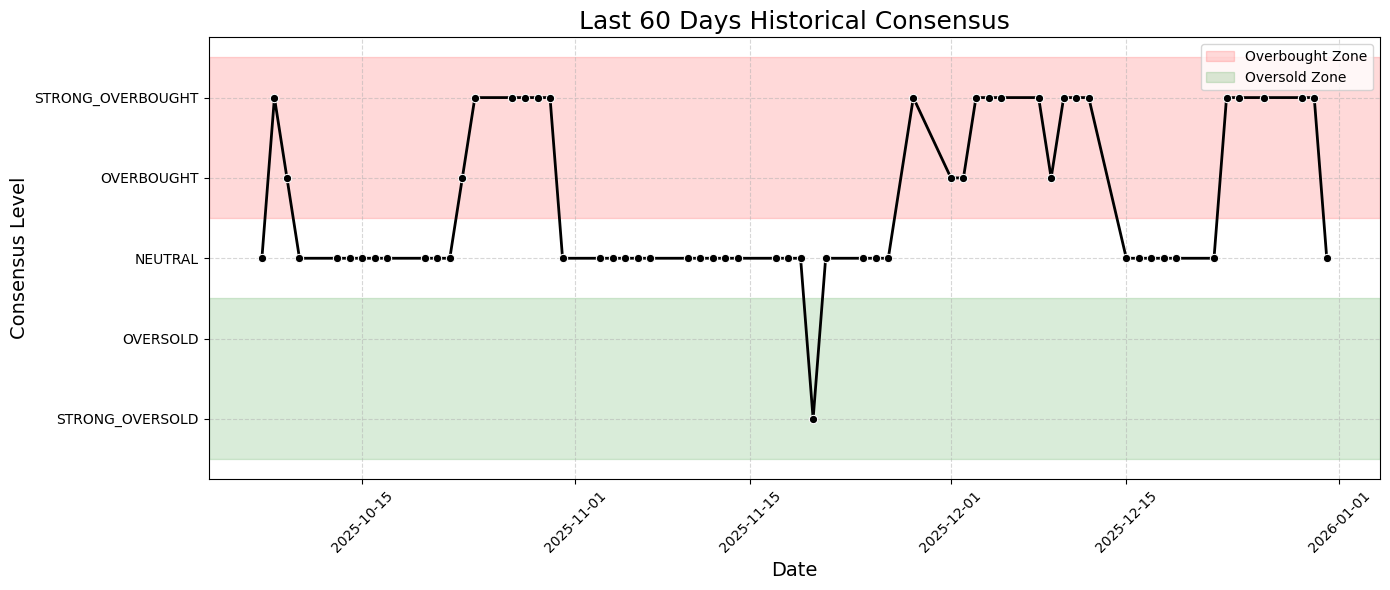

In [23]:
# -----------------------------
# Last 60 Days Historical Consensus (with zones)
# -----------------------------

hist = df3.tail(60).copy()
hist["CONS_LEVEL"] = hist["CONSENSUS"].map(class_to_idx)

plt.figure(figsize=(14, 6))

# Consensus line
sns.lineplot(
    data=hist,
    x=hist.index,
    y="CONS_LEVEL",
    marker="o",
    linewidth=2,
    markersize=6,
    color="black"
)

# --- Shaded Zones ---
# Overbought zone (levels 3–4)
plt.axhspan(3 - 0.5, 4 + 0.5, color="red", alpha=0.15, label="Overbought Zone")

# Oversold zone (levels 0–1)
plt.axhspan(0 - 0.5, 1 + 0.5, color="green", alpha=0.15, label="Oversold Zone")

# Labels and formatting
plt.title("Last 60 Days Historical Consensus", fontsize=18)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Consensus Level", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5)

plt.yticks(
    ticks=[4, 3, 2, 1, 0],
    labels=[
        "STRONG_OVERBOUGHT",
        "OVERBOUGHT",
        "NEUTRAL",
        "OVERSOLD",
        "STRONG_OVERSOLD"
    ]
)

plt.xticks(rotation=45)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("./Documents/60daysConsenus.png")
plt.show()


In [24]:
# -----------------------------
# Dataset: Converts NumPy → Tensor
# -----------------------------
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# -----------------------------
# CNN model: CNN expects input shaped like: (batch, channels=1, features)
# -----------------------------
import torch
import torch.nn as nn

class DeeperCNN1D(nn.Module):
    """
    12-Layer Deep 1D CNN for Financial Regime Classification
    Balanced depth, controlled channel growth, strong regularization.
    """

    def __init__(self, n_features, n_classes):
        super().__init__()

        def conv_block(in_c, out_c, dropout=0.0):
            return nn.Sequential(
                nn.Conv1d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm1d(out_c),
                nn.ReLU(),
                nn.Dropout(dropout)
            )

        # 12 convolutional layers grouped into 6 blocks
        self.conv = nn.Sequential(
            conv_block(1, 32),
            conv_block(32, 32),

            conv_block(32, 64),
            conv_block(64, 64, dropout=0.1),

            conv_block(64, 64),
            conv_block(64, 64),

            conv_block(64, 128),
            conv_block(128, 128, dropout=0.2),

            conv_block(128, 128),
            conv_block(128, 128),

            conv_block(128, 128),
            conv_block(128, 128, dropout=0.3),
        )

        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.fc = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.global_pool(x).squeeze(-1)
        x = self.fc(x)
        return x

# -----------------------------
# Early stopping
# -----------------------------
class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = np.inf
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


In [25]:
# -----------------------------
# Train / eval functions
# -----------------------------
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    avg_loss = running_loss / len(loader.dataset)
    avg_acc = correct / total
    return avg_loss, avg_acc


def eval_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_loss += loss.item() * X_batch.size(0)

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

            all_preds.append(preds.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    avg_acc = correct / total
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    return avg_loss, avg_acc, all_preds, all_targets

In [26]:
# -----------------------------
# 2x2 dashboard plotting
# -----------------------------
def plot_dashboard(history, y_true, y_pred, title_suffix=""):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Loss
    axes[0, 0].plot(history["train_loss"], label="Train Loss", linewidth=2)
    axes[0, 0].plot(history["val_loss"], label="Val Loss", linewidth=2)
    axes[0, 0].set_title("Loss")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # Accuracy
    axes[0, 1].plot(history["train_acc"], label="Train Acc", linewidth=2)
    axes[0, 1].plot(history["val_acc"], label="Val Acc", linewidth=2)
    axes[0, 1].set_title("Accuracy")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Accuracy")
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # Learning rate
    axes[1, 0].plot(history["lr"], label="LR", linewidth=2)
    axes[1, 0].set_title("Learning Rate")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("LR")
    axes[1, 0].grid(True)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=[idx_to_class[i] for i in range(len(target_classes))],
        columns=[idx_to_class[i] for i in range(len(target_classes))]
    )
    sns.heatmap(
        cm_df,
        annot=True,
        fmt="d",
        cmap="Blues",
        linewidths=0.5,
        linecolor="gray",
        cbar=True,
        ax=axes[1, 1]
    )
    axes[1, 1].set_title("Confusion Matrix")
    axes[1, 1].set_xlabel("Predicted")
    axes[1, 1].set_ylabel("True")

    fig.suptitle(f"Training Dashboard {title_suffix}", fontsize=16)
    plt.tight_layout()
    plt.savefig("./Documents/Dashboard.png")
    plt.show()

In [27]:
# -----------------------------
# Train/test split (single-day)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Class distribution BEFORE SMOTE:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"{idx_to_class[u]}: {c}")

# -----------------------------
# SMOTE + class weights
# -----------------------------
assert df3["TARGET_IDX"].isna().sum() == 0, "NaN labels detected!"

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

assert set(np.unique(y_train_res)) == {0,1,2,3,4}, "Invalid labels after SMOTE!"


print("\nClass distribution AFTER SMOTE:")
unique_res, counts_res = np.unique(y_train_res, return_counts=True)
for u, c in zip(unique_res, counts_res):
    print(f"{idx_to_class[u]}: {c}")

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_res),
    y=y_train_res
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

Class distribution BEFORE SMOTE:
STRONG_OVERSOLD: 93
OVERSOLD: 52
NEUTRAL: 1024
OVERBOUGHT: 162
STRONG_OVERBOUGHT: 631

Class distribution AFTER SMOTE:
STRONG_OVERSOLD: 1024
OVERSOLD: 1024
NEUTRAL: 1024
OVERBOUGHT: 1024
STRONG_OVERBOUGHT: 1024



Selected features by RF:
['ADX', 'ADX_NEG', 'ADX_POS', 'BB_PBAND', 'MACD_HIST', 'MFI', 'RSI', 'STOCHRSI', 'STOCH_D', 'STOCH_K', 'STOCH_SLOW_D', 'STOCH_SLOW_K', 'ULTIMATE_OSC', 'WILLIAMS_R']


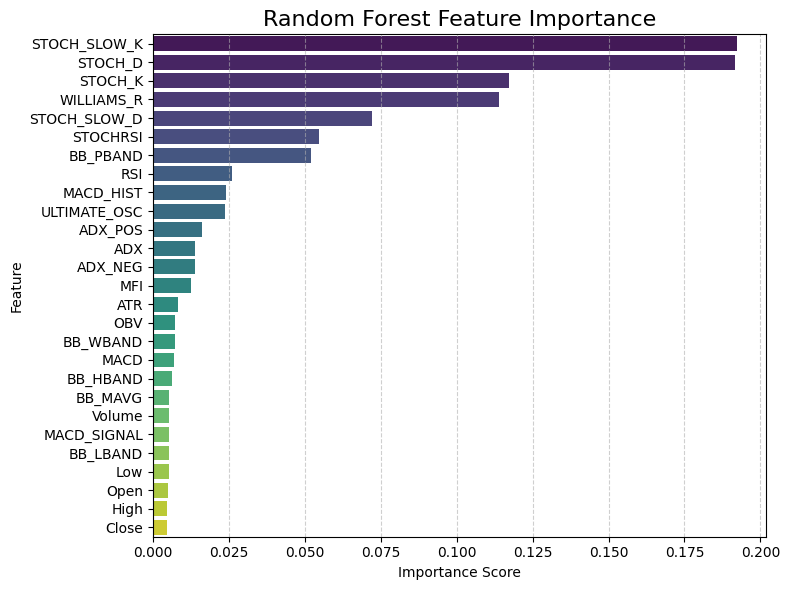

In [28]:
# -----------------------------
#  RF feature selection
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)
rf.fit(X_train_res, y_train_res)

selector = SelectFromModel(rf, prefit=True, threshold="median")
X_train_sel = selector.transform(X_train_res)
X_test_sel = selector.transform(X_test)

selected_mask = selector.get_support()
selected_features = [f for f, m in zip(feature_cols, selected_mask) if m]
print("\nSelected features by RF:")
print(selected_features)

# -----------------------------
# Plot RF Feature Importance
# -----------------------------

# Raw importances for all features
importances = rf.feature_importances_

# Put into a DataFrame for easy sorting
fi_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": importances
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=fi_df,
    x="Importance",
    y="Feature",
    palette="viridis"
)
plt.title("Random Forest Feature Importance", fontsize=16)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("./Documents/rf_selection.png")
plt.show()



In [29]:
# -----------------------------
# Scaling
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

# CNN input: (batch, 1, seq_len)
X_train_cnn = X_train_scaled[:, np.newaxis, :]
X_test_cnn = X_test_scaled[:, np.newaxis, :]

# It converts NumPy arrays → PyTorch tensors
train_dataset = TimeSeriesDataset(X_train_cnn, y_train_res)
test_dataset = TimeSeriesDataset(X_test_cnn, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [30]:
# -----------------------------
#  Model, optimizer, scheduler
# -----------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = torch.device("cpu")

n_features_sel = X_train_cnn.shape[2]
n_classes = len(target_classes)
#print("n_classes =", n_classes)

model = DeeperCNN1D(n_features=n_features_sel, n_classes=n_classes).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device), label_smoothing=0.05)   #Label smoothing is a regularization technique that softens the target labels
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)  # Add a small weight decay (L2 regularization)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.3, patience=2, verbose=True
)

early_stopping = EarlyStopping(patience=15, min_delta=1e-4)

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": []
}

best_val_acc = 0.0
best_epoch = 0
checkpoint_dir = "./Docments/"
os.makedirs(checkpoint_dir, exist_ok=True)
ckpt_path = os.path.join(checkpoint_dir, "best_model_single_day.pt")


In [31]:
# -----------------------------
#  Training loop
# -----------------------------
max_epochs = 100
print(f"{'Epoch':<6} {'TrainLoss':<12} {'TrainAcc':<10} {'ValLoss':<10} {'ValAcc':<10} {'LR'}")

for epoch in range(1, max_epochs + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, _, _ = eval_epoch(model, val_loader, criterion, device)

    scheduler.step(val_loss)
    lr = optimizer.param_groups[0]['lr']

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(lr)

    print(f"{epoch:<6} {train_loss:<12.6f} {train_acc:<10.4f} "
          f"{val_loss:<10.6f} {val_acc:<10.4f} {lr:.6f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "val_acc": val_acc
        }, ckpt_path)

    early_stopping(val_loss)
    if early_stopping.early_stop:
        print("Early stopping triggered.")
        break

print(f"\nBest Validation Accuracy: {best_val_acc:.4f} at epoch {best_epoch}")
print(f"Best model checkpoint saved to: {ckpt_path}")

Epoch  TrainLoss    TrainAcc   ValLoss    ValAcc     LR
1      0.813179     0.7336     1.786753   0.5316     0.001000
2      0.608779     0.8303     0.667714   0.8248     0.001000
3      0.556221     0.8635     0.627521   0.8228     0.001000
4      0.515464     0.8750     0.639687   0.8248     0.001000
5      0.473882     0.8955     0.553736   0.8289     0.001000
6      0.447458     0.9109     0.589123   0.8371     0.001000
7      0.428934     0.9174     0.678699   0.8289     0.001000
8      0.415614     0.9246     0.572050   0.8554     0.000300
9      0.369972     0.9463     0.550304   0.8635     0.000300
10     0.352702     0.9557     0.674609   0.7984     0.000300
11     0.346263     0.9555     0.490943   0.8921     0.000300
12     0.343335     0.9568     0.569382   0.8513     0.000300
13     0.328598     0.9613     0.479197   0.8961     0.000300
14     0.330446     0.9625     0.500461   0.8737     0.000300
15     0.333099     0.9598     0.459360   0.9043     0.000300
16     0.34071


Classification Report:
                   precision    recall  f1-score   support

  STRONG_OVERSOLD       0.75      0.86      0.80        14
         OVERSOLD       0.38      0.62      0.48         8
          NEUTRAL       0.99      0.95      0.97       243
       OVERBOUGHT       0.66      0.81      0.73        48
STRONG_OVERBOUGHT       0.94      0.90      0.92       178

         accuracy                           0.91       491
        macro avg       0.74      0.83      0.78       491
     weighted avg       0.92      0.91      0.91       491

Confusion Matrix:
[[ 12   2   0   0   0]
 [  3   5   0   0   0]
 [  1   6 230   4   2]
 [  0   0   1  39   8]
 [  0   0   2  16 160]]


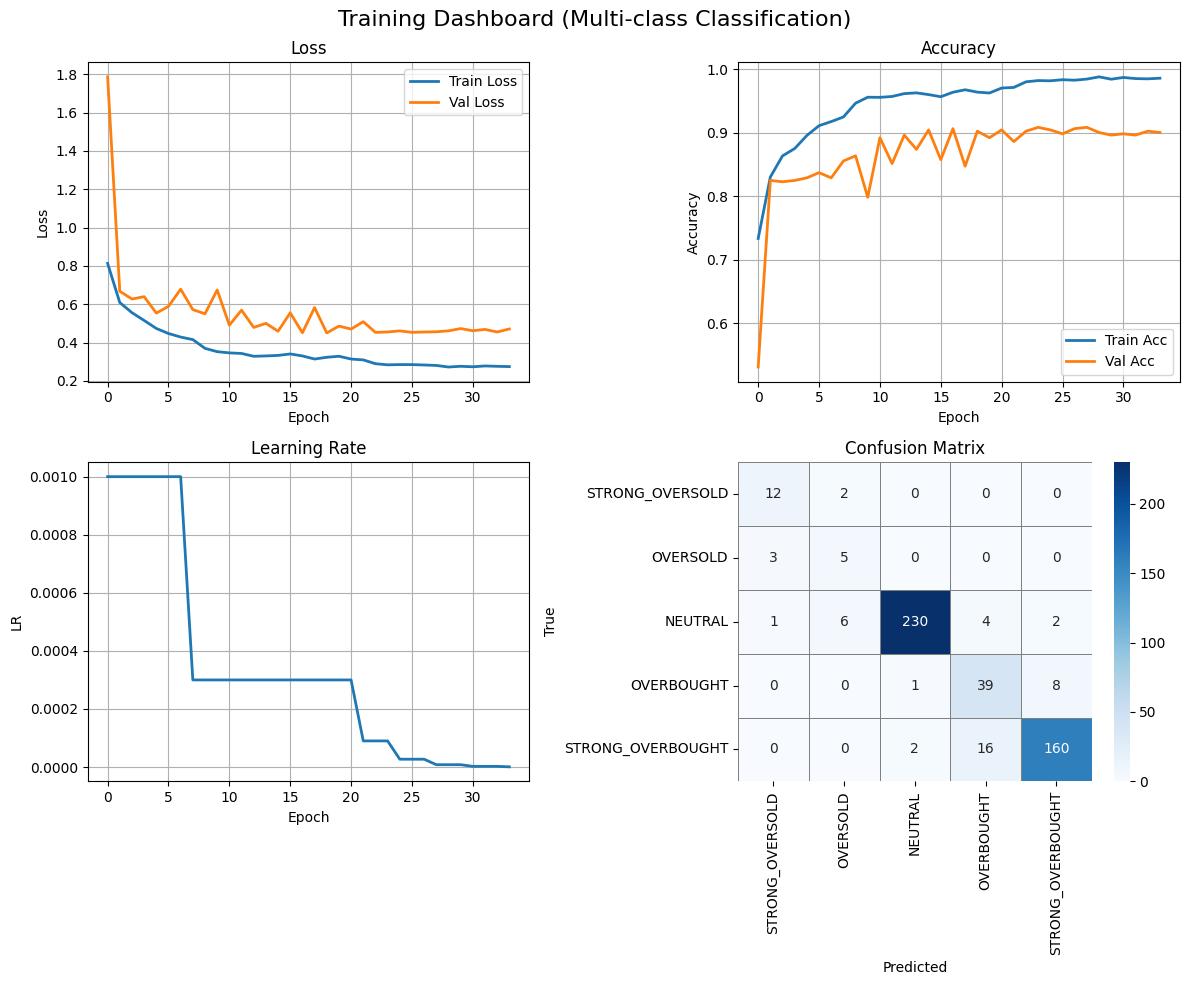

In [32]:
# -----------------------------
# Final evaluation with best model
# -----------------------------
checkpoint = torch.load(ckpt_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

val_loss, val_acc, y_pred, y_true = eval_epoch(model, val_loader, criterion, device)

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=[idx_to_class[i] for i in range(len(target_classes))]
))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

# 2x2 dashboard
plot_dashboard(history, y_true, y_pred, title_suffix="(Multi-class Classification)")


In [33]:
# -----------------------------
#  Next-step consensus prediction
# -----------------------------
last_row = df3.iloc[-1]
last_features = np.array(last_row[feature_cols])[np.newaxis, :]
last_features_sel = selector.transform(last_features)
last_features_scaled = scaler.transform(last_features_sel)
last_features_cnn = torch.tensor(
    last_features_scaled[:, np.newaxis, :],
    dtype=torch.float32
).to(device)

model.eval()
with torch.no_grad():
    logits = model(last_features_cnn)
    pred_idx = torch.argmax(logits, dim=1).item()
    pred_class = idx_to_class[pred_idx]

print("\nNext-step consensus prediction:")
print(f"Predicted regime: {pred_class}")



Next-step consensus prediction:
Predicted regime: NEUTRAL
